<a href="https://colab.research.google.com/github/arman-hossain45/Heart_Disease_prediction_With_Gradio/blob/main/foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

#model selection
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier,StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("heart.csv")
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.5 MB/s eta 0:00:00


In [8]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df,title="Heart Disease Report")
profile.to_file("ydata.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 31.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
numerical_feature = df.select_dtypes(include=['int64','float64'])
categorical_feature = df.select_dtypes(include=['object'])

In [10]:
numerical_feature

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [11]:
categorical_feature

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


***See outliar in this data set***

<Axes: >

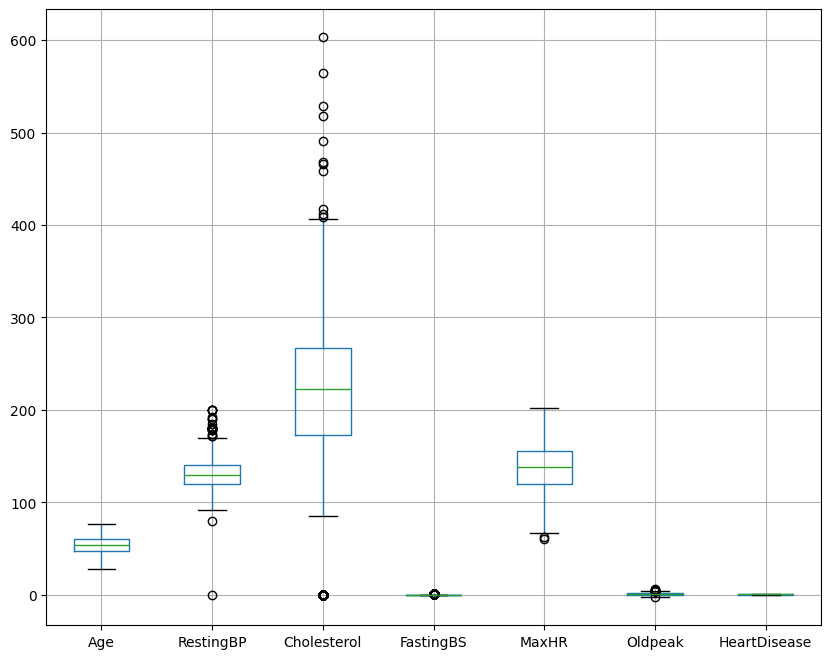

In [12]:
plt.figure(figsize=(10,8))
df[numerical_feature.columns].boxplot()

***Handle Outliar of this data set***

In [13]:

# handle the outliar
col='Cholesterol'
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1

lower=q1=1.5*IQR
upper=q3+1.5*IQR

outliers=df[(df[col]<lower)|(df[col]>upper)]
print(f'Number of detected outlier is {col}',len(outliers))

Number of detected outlier is Cholesterol 197


In [14]:

#cap outliers (winsorization like approch)

df = df.copy()   # Create a copy and STORE it

df[col] = df[col].clip(lower, upper)   # Apply winsorization
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.000,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.000,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.000,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.000,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.000,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264.000,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193.000,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,140.625,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.000,0,LVH,174,N,0.0,Flat,1


<Axes: >

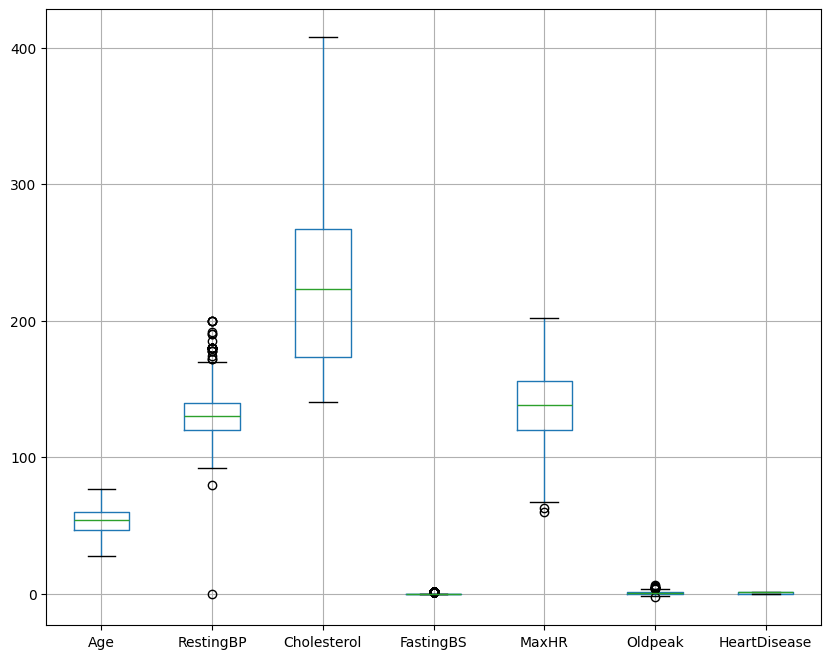

In [15]:
plt.figure(figsize=(10,8))
df[numerical_feature.columns].boxplot()

In [16]:
# handle the outliar
col='RestingBP'
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1

lower=q1=1.5*IQR
upper=q3+1.5*IQR

outliers=df[(df[col]<lower)|(df[col]>upper)]
print(f'Number of detected outlier is {col}',len(outliers))

Number of detected outlier is RestingBP 27


In [17]:
df = df.copy()   # Create a copy and STORE it

df[col] = df[col].clip(lower, upper)

<Axes: >

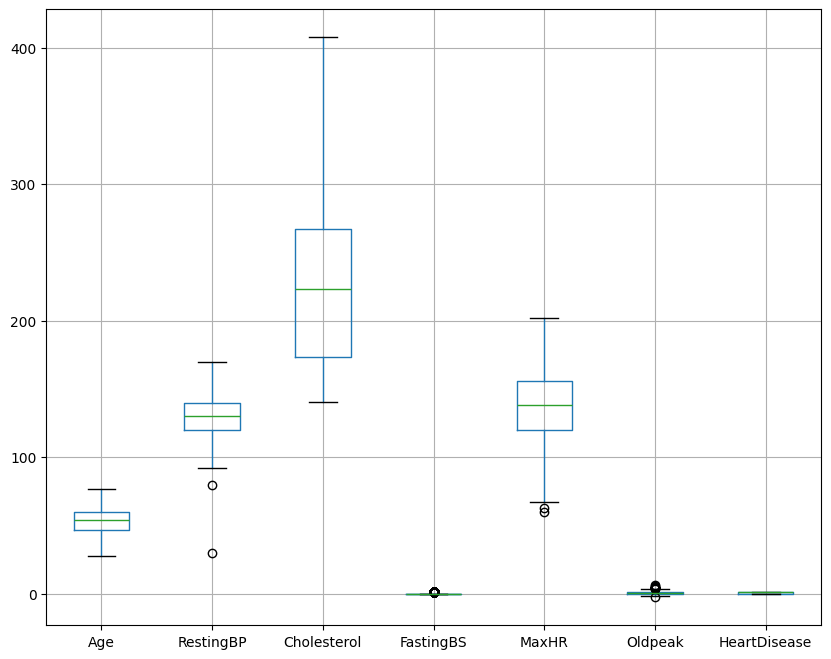

In [18]:
plt.figure(figsize=(10,8))
df[numerical_feature.columns].boxplot()

### Re-running the pipeline from `x` and `y` separation with corrected feature definitions.

In [58]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [19]:
# Separate x and y
x=df.drop("HeartDisease",axis=1)
y=df['HeartDisease']

# Redefine numerical and categorical features based on x
numerical_feature = x.select_dtypes(include=['int64','float64'])
categorical_feature = x.select_dtypes(include=['object'])

In [20]:
#if we want to delete any column in this data set is

# if 'date' in df.columns:
#   df.drop(columns=['date'],inplace=true)

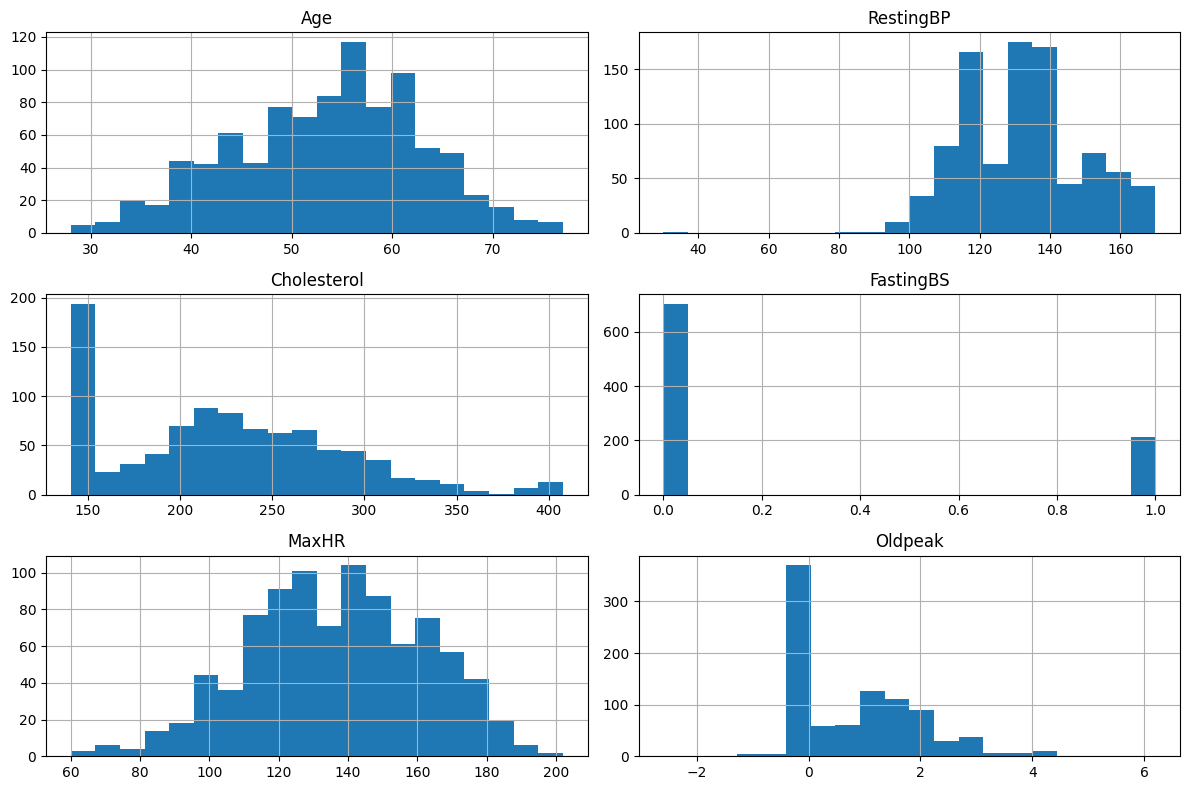

In [21]:
df[numerical_feature.columns].hist(bins=20,figsize=(12,8))
plt.tight_layout()
plt.show()

*Correlation for Numerical Value*

In [22]:
corr_target = df.select_dtypes(include=np.number).corr()['HeartDisease'].sort_values(ascending=False)

In [23]:
corr_target

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.108500
Cholesterol,-0.129437
MaxHR,-0.400421


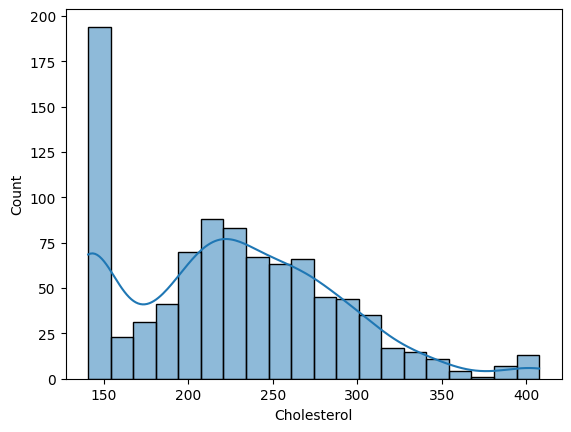

In [24]:
sns.histplot(df['Cholesterol'],kde=True,bins=20)
plt.show()

***Separate x and y***

here in this code if y is catagorical value than we do this below code in details

In [26]:
#from sklearn.preprocessing import labelEncoder
#le = LabelEncoder()
#y_encoded = le.fit_transform(y)

***if in our Data set there is some row which has ordinal and one_hot encoded is needed than do this below code in details ***

onehot_col=['gender',''city']

ordinal_col=['Education']

numerical_col =['Age','Salary']


onehot_pipeline=Pipeline(steps=[
  ("imputer",SimpleImputer(strategy="most_frequent")),

  ("onehot",)



***Numerical and categorical column***

In [27]:
numerical_feature

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140,289.000,0,172,0.0
1,49,160,180.000,0,156,1.0
2,37,130,283.000,0,98,0.0
3,48,138,214.000,0,108,1.5
4,54,150,195.000,0,122,0.0
...,...,...,...,...,...,...
913,45,110,264.000,0,132,1.2
914,68,144,193.000,1,141,3.4
915,57,130,140.625,0,115,1.2
916,57,130,236.000,0,174,0.0


In [28]:
categorical_feature

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


#pipeline

In [29]:
# for numerical feature

num_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

In [30]:
num_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [31]:
# for categorical feature

cat_trasformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
cat_trasformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

***combine both of them***

In [33]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',num_transformer,numerical_feature.columns),
        ('cat',cat_trasformer,categorical_feature.columns)
    ]
)

***Train test split***

In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#Base learner algorithom


In [35]:

#Logistic Regression
lr=LogisticRegression(max_iter = 2000,class_weight='balanced')
#Decision Tree classifier
dt=DecisionTreeClassifier( max_depth =3,random_state=42)
#Random forest
rf=RandomForestClassifier(max_depth=None,max_features='sqrt',n_estimators=50)
#KNN
knn=KNeighborsClassifier(n_neighbors=15,metric='minkowski',p=2)
#SVM
svm=SVC(kernel='rbf',gamma='scale',C=5,random_state=42)
gb=GradientBoostingClassifier(n_estimators=150,learning_rate=0.05,max_depth=3
                              ,subsample=0.8,random_state=42)


***voting classifier***

In [36]:
voting_class=VotingClassifier(
    estimators=[
        ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('knn',knn),
        ('svm',svm),
        ('gb',gb)
    ],
    voting='hard'
)

***stacking classifier***

In [37]:
Stacking_classifier=StackingClassifier(
    estimators=[
         ('lr',lr),
        ('dt',dt),
        ('rf',rf),
        ('knn',knn),
        ('svm',svm),
        ('gb',gb)
    ],
    final_estimator=RidgeClassifier()
)

***tranning model***

In [38]:
model_to_train={
    'Logistic Regression' : lr,
    'Decision Tree' : dt,
    'Random Forest' : rf,
    'knn' : knn,
    'svm' : svm,
    'Gradient Boosting' : gb,
    'voting classifier' : voting_class,
    "stacking classifier": Stacking_classifier
}

***Tranning and evaluation***

In [39]:
result =[]
for model_name,model in model_to_train.items():
  #create a full pipe line with preprocessor
  pipe=Pipeline([
      ("preprocessor",preprocessor),
      ('model',model)
  ])
  #train the model
  pipe.fit(x_train,y_train)

  #predict
  y_pred = pipe.predict(x_test)

  #evaluate
  accuracy=accuracy_score(y_test,y_pred)

  result.append(
      {
          "Model" :model_name,
          "accuracy" : accuracy
      }
  )

In [40]:
res_df=pd.DataFrame(result).sort_values(by="accuracy",ascending=False)
print(res_df)

                 Model  accuracy
7  stacking classifier  0.891304
5    Gradient Boosting  0.875000
6    voting classifier  0.875000
3                  knn  0.869565
2        Random Forest  0.869565
4                  svm  0.864130
0  Logistic Regression  0.842391
1        Decision Tree  0.836957


In [41]:
best_model=res_df.iloc[0]['Model']
best_model_score=model_to_train[best_model]

#fit the final model

final_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ('model',best_model_score)
])

final_pipeline.fit(x_train,y_train)
y_final_pred = final_pipeline.predict(x_test)
final_accuracy = accuracy_score(y_test,y_final_pred)
final_accuracy

0.8913043478260869

In [42]:
cm = confusion_matrix(y_test, y_final_pred)
report = classification_report(y_test, y_final_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[68  9]
 [11 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87        77
           1       0.91      0.90      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



# Cross validation

Model is random forest best model for this data set

In [43]:
rf_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ('model',RandomForestClassifier(max_depth=None,max_features ='sqrt',n_estimators=50))
])

***5 fold cross validation***

In [44]:
cv_result= cross_val_score(rf_pipeline,x_train,y_train,cv=5,scoring='accuracy')

cv_accuracy = cv_result.mean()
cv_std = cv_result.std()
cv_accuracy,cv_std,cv_result

(np.float64(0.8596682508619885),
 np.float64(0.010241030356858728),
 array([0.86394558, 0.87755102, 0.85034014, 0.85034014, 0.85616438]))

#Grid search CV

***Random Forest***

In [45]:
param_grid = {
    'model__n_estimators' : [50,100,200],
    'model__max_depth' :[None,5,10,15],
    'model__max_features':['sqrt','log2'],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[2,3,4]
}

In [46]:
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [47]:
grid_search_rf.fit(x_train,y_train)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')...
                                                                         Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=50))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 15],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [2, 3, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [48]:
grid_search_rf.best_params_

{'model__max_depth': 15,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [49]:
grid_search_rf.best_score_

np.float64(0.8719317864131954)

In [50]:
rf_pipeline2 = Pipeline([
    ("preprocessor",preprocessor),
    ('model',RandomForestClassifier(max_depth=None,max_features ='sqrt',n_estimators=50,min_samples_split=2))
])

In [51]:
rf_pipeline2.fit(x_train,y_train)
y_final_pred2 = rf_pipeline2.predict(x_test)
final_accuracy2 = accuracy_score(y_test,y_final_pred2)
final_accuracy2

0.875

In [52]:
cm = confusion_matrix(y_test, y_final_pred2)
report = classification_report(y_test, y_final_pred2)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Confusion Matrix:
 [[68  9]
 [14 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86        77
           1       0.91      0.87      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



Save the model

In [53]:
import pickle

In [54]:
filename='random_forest_model.pkl'
with open(filename,'wb') as file:
  pickle.dump(rf_pipeline2,file)

In [55]:
with open("/content/random_forest_model.pkl", 'rb') as file:
  rf_loaded_model = pickle.load(file)

In [56]:
rf_loaded_model.predict(x_test)

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1])

In [57]:
rf_loaded_model.predict(x_test)

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1])